# Experiment: Two-Phase Ricci-Based Architecture Screening

**Dataset**: Fashion-MNIST (Sneakers vs Sandals)

**Hypothesis**: A Ricci coefficient that remains shallow (close to 0) after a short
probe run signals that the architecture is *geometrically immature* — it has not yet
begun curvature-driven flow — and therefore needs a larger training budget rather
than being discarded.

## Protocol

| Phase | What happens |
|-------|-------------|
| **Phase 1 — Probe** | Train ALL 45 architectures for exactly `PHASE1_EPOCHS` epochs (no early stopping). At the end, compute each architecture's robust avg Ricci score. |
| **Selection** | Flag architectures whose avg Ricci after Phase 1 is above `RICCI_SELECTION_THRESHOLD` (i.e. still shallow / not yet flowing). |
| **Phase 2 — Extended** | Train only the flagged architectures for `PHASE2_EPOCHS` epochs. Standard ES runs as a **passive observer** throughout. Save full history, activations, and model weights at every epoch. |

**Key question**: Do the geometrically immature architectures eventually reach
comparable accuracy when given more training budget?


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, time, json, copy
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset
from scipy.sparse import csr_matrix, lil_matrix
from scipy.sparse import triu as sp_triu
from scipy.sparse.csgraph import dijkstra
from sklearn.neighbors import kneighbors_graph
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')


Device: cpu


In [ ]:
PHASE1_EPOCHS = 10       # Short probe: all 45 architectures run for this many epochs
PHASE2_EPOCHS = 200      # Extended run: only flagged architectures

# ── Selection criterion
# Architectures whose robust avg Ricci after Phase 1 is ABOVE this threshold
# are considered geometrically immature and selected for Phase 2.
# "Above" = closer to 0 = not yet flowing.
# Tune this based on your Phase 1 distribution; -0.3 is a reasonable starting point.
RICCI_SELECTION_THRESHOLD = -0.6

# ── Standard early stopping (passive observer in Phase 2) ──
PATIENCE = 5

# ── kNN ──
K_FRAC = 0.05            # k = 5% of test-set size (paper Appendix A.5.1)
# K is set after the test set is loaded

# ── Curvature type ──
CURVATURE_TYPE = 'Augmented-Forman-Ricci'

# ── Training ──
LR = 0.001
BATCH_SIZE = 512

# ── Architecture grid (identical to existing experiment) ──
FLAT_DEPTHS      = [4, 5, 6, 7, 8, 9, 10, 11, 12]
FLAT_WIDTHS      = [16, 32, 64, 128]
BOTTLENECK_DEPTHS = [4, 5, 6, 7, 8, 9, 10, 11, 12]
BOTTLENECK_WIDTH  = 128

ARCHITECTURES = []
for d in FLAT_DEPTHS:
    for w in FLAT_WIDTHS:
        ARCHITECTURES.append((f'flat_{d}_{w}', 'flat', d, w))
for d in BOTTLENECK_DEPTHS:
    ARCHITECTURES.append((f'bottleneck_{d}_{BOTTLENECK_WIDTH}', 'bottleneck', d, BOTTLENECK_WIDTH))

print(f'Total architectures: {len(ARCHITECTURES)}')
print(f'Flat: {len(FLAT_DEPTHS)*len(FLAT_WIDTHS)}, Bottleneck: {len(BOTTLENECK_DEPTHS)}')

# ── Output paths
DRIVE_BASE   = '/content/drive/MyDrive/Ricci_Flow_Experiment'
OUTPUT_DIR   = os.path.join(DRIVE_BASE, 'two_phase_experiment')
PHASE1_DIR   = os.path.join(OUTPUT_DIR, 'phase1')
PHASE2_DIR   = os.path.join(OUTPUT_DIR, 'phase2')
PHASE1_CKPT  = os.path.join(OUTPUT_DIR, 'phase1_checkpoint.json')
PHASE2_CKPT  = os.path.join(OUTPUT_DIR, 'phase2_checkpoint.json')

for d in [OUTPUT_DIR, PHASE1_DIR, PHASE2_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Output root: {OUTPUT_DIR}')


Total architectures: 45
Flat: 36, Bottleneck: 9
Output root: /content/drive/MyDrive/Ricci_Flow_Experiment/two_phase_experiment


In [ ]:
# ── Load Fashion-MNIST (Sneakers=7 vs Sandals=5)
transform  = transforms.Compose([transforms.ToTensor()])
train_data = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

def filter_classes(dataset, class_a=5, class_b=7):
    mask = (dataset.targets == class_a) | (dataset.targets == class_b)
    X    = dataset.data[mask].float() / 255.0
    y    = dataset.targets[mask].float()
    y    = (y == class_b).float()   # Sneakers=1, Sandals=0
    return X.to(device), y.to(device)

X_train, y_train = filter_classes(train_data)
X_test,  y_test  = filter_classes(test_data)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Batches per epoch: {len(train_loader)}')
print(f'Class balance — Train: {y_train.mean():.3f}, Test: {y_test.mean():.3f}')

# ── kNN k = 5% of test set (paper Appendix A.5.1)
K = max(1, int(round(K_FRAC * X_test.shape[0])))
print(f'kNN k = {K}  (= {K_FRAC*100:.0f}% of {X_test.shape[0]} test samples)')


100%|██████████| 26.4M/26.4M [00:02<00:00, 9.10MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 141kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.4MB/s]


Train: torch.Size([12000, 28, 28]), Test: torch.Size([2000, 28, 28])
Batches per epoch: 24
Class balance — Train: 0.500, Test: 0.500
kNN k = 100  (= 5% of 2000 test samples)


In [ ]:
def get_bottleneck_widths(depth, max_width):
    """Generate symmetric bottleneck widths.
    E.g. depth=5, max_width=128 -> [128, 64, 32, 64, 128]
    """
    mid = depth // 2
    widths = []
    for i in range(depth):
        dist_from_mid = abs(i - mid)
        if depth % 2 == 0:
            dist_from_mid  = abs(i - mid + 0.5) + 0.5
            dist_from_edge = min(i, depth - 1 - i)
        else:
            dist_from_edge = min(i, depth - 1 - i)
        reduction = 2 ** (mid - dist_from_edge) if dist_from_edge < mid else 1
        w = max(max_width // reduction, 8)
        widths.append(w)
    return widths


class DNN(nn.Module):
    def __init__(self, input_dim=784, layer_widths=None, hidden_units=None, depth=None):
        super().__init__()
        if layer_widths is None:
            layer_widths = [hidden_units] * depth
        self.flatten = nn.Flatten()

        dims = [input_dim] + layer_widths + [1]

        layers = []
        for i in range(len(dims) - 1):
            linear = nn.Linear(dims[i], dims[i + 1])
            nn.init.kaiming_normal_(linear.weight, nonlinearity='relu')
            nn.init.zeros_(linear.bias)
            layers.append(linear)
        self.layers     = nn.ModuleList(layers)
        self.batchnorms = nn.ModuleList([
            nn.BatchNorm1d(dims[i + 1]) for i in range(len(dims) - 2)
        ])

    def forward(self, x):
        x = self.flatten(x)
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = self.batchnorms[i](x)
            x = torch.relu(x)
        return self.layers[-1](x)

    def features(self, x):
        x = self.flatten(x)
        feats = [x.detach().cpu().numpy()]           # index 0: flattened input
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = self.batchnorms[i](x)
            x = torch.relu(x)
            feats.append(x.detach().cpu().numpy())   # indices 1..L: hidden layers
        # Output layer (sigmoid) deliberately NOT appended
        return feats


def build_model(arch_type, depth, width):
    if arch_type == 'bottleneck':
        widths = get_bottleneck_widths(depth, width)
        model  = DNN(input_dim=784, layer_widths=widths)
    else:
        model  = DNN(input_dim=784, hidden_units=width, depth=depth)
    return model.to(device)


# Smoke test
_m = build_model('flat', 5, 64)
print(f'Flat 5/64: {[(l.in_features, l.out_features) for l in _m.layers]}')
del _m
print('\u2705 DNN defined')


Flat 5/64: [(784, 64), (64, 64), (64, 64), (64, 64), (64, 64), (64, 1)]
✅ DNN defined


In [ ]:
def accuracy_fn(y_true, y_pred):
    return (torch.eq(y_true, y_pred).sum().item() / len(y_pred)) * 100

def train_one_epoch(model, train_loader, optimizer, loss_fn):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        y_logits = model(X_batch).squeeze()
        loss = loss_fn(y_logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(train_loader.dataset)

def evaluate(model, X, y):
    model.eval()
    with torch.inference_mode():
        y_logits = model(X).squeeze()
        y_preds  = torch.round(torch.sigmoid(y_logits))
        acc  = accuracy_fn(y, y_preds) / 100.0
        loss = nn.BCEWithLogitsLoss()(y_logits, y).item()
    return acc, loss

print('\u2705 Training utilities defined')


✅ Training utilities defined


In [ ]:
def compute_forman_ricci(A):
    A       = csr_matrix(A)
    degrees = A @ np.ones(A.shape[0])
    Ric     = lil_matrix(A.shape, dtype=np.int32)
    rows, cols = sp_triu(A, k=1).nonzero()
    for i, j in zip(rows, cols):
        Ric[i, j] = 4 - degrees[i] - degrees[j]
        Ric[j, i] = Ric[i, j]
    return Ric.tocsr()

def compute_augmented_forman_ricci(A):
    A       = csr_matrix(A)
    degrees = A @ np.ones(A.shape[0])
    A2      = A @ A
    Ric     = lil_matrix(A.shape, dtype=np.int32)
    rows, cols = sp_triu(A, k=1).nonzero()
    for i, j in zip(rows, cols):
        Ric[i, j] = 4 - degrees[i] - degrees[j] + 3 * A2[i, j]
        Ric[j, i] = Ric[i, j]
    return Ric.tocsr()

def compute_approx_ollivier_ricci(A):
    A       = csr_matrix(A)
    degrees = A @ np.ones(A.shape[0])
    A2      = A @ A
    Ric     = lil_matrix(A.shape, dtype=np.float32)
    rows, cols = sp_triu(A, k=1).nonzero()
    for i, j in zip(rows, cols):
        t  = A2[i, j]; di, dj = degrees[i], degrees[j]
        Ric[i, j] = (0.5 * (t / max(di, dj))
                     - 0.5 * (max(0, 1 - 1/di - 1/dj - t/min(di, dj))
                               + max(0, 1 - 1/di - 1/dj - t/max(di, dj))
                               - t / max(di, dj)))
        Ric[j, i] = Ric[i, j]
    return Ric.tocsr()

def compute_curvature(A, curv):
    if   curv == 'Forman-Ricci':            return compute_forman_ricci(A)
    elif curv == 'Augmented-Forman-Ricci':  return compute_augmented_forman_ricci(A)
    elif curv == 'Approx-Ollivier-Ricci':   return compute_approx_ollivier_ricci(A)
    else: raise ValueError(f'Unknown curvature: {curv}')

def compute_ricci_from_features(features, k, curv='Augmented-Forman-Ricci'):
    """
    Compute layer Ricci coefficients (paper Section 3.2).
    features: list of 2D arrays [input, hidden_1, ..., hidden_L]
              (output layer excluded — paper faithfulness)
    Returns array of shape (len(features)-1,).
    """
    depth = len(features)
    kNN_graphs = []
    for feat in features:
        g = kneighbors_graph(feat, k, mode='connectivity', include_self=False)
        kNN_graphs.append(g.maximum(g.T))
    apsps      = [dijkstra(csgraph=g, directed=False, unweighted=True,
                           return_predecessors=False) for g in kNN_graphs]
    curvatures = [compute_curvature(kNN_graphs[i], curv) for i in range(depth - 1)]

    layer_ricci = np.empty(depth - 1)
    for i in range(depth - 1):
        sc, eta = [], []
        for x in range(len(features[0])):
            S1 = kNN_graphs[i][x].indices
            ec, connected = 0, True
            for y in S1:
                if apsps[i + 1][x, y] == np.inf:
                    connected = False
                else:
                    ec += apsps[i + 1][x, y] - apsps[i][x, y]
            if connected:
                sc.append(np.divide(curvatures[i][x].sum(),
                                    kNN_graphs[i][x].count_nonzero()))
                eta.append(ec / len(S1))
        layer_ricci[i] = pearsonr(sc, eta)[0] if len(sc) >= 2 else np.nan
    return layer_ricci

print('\u2705 Curvature functions defined')


✅ Curvature functions defined


In [ ]:
def robust_avg_ricci_iqr(layer_ricci, iqr_factor=1.5):
    valid_mask = np.isfinite(layer_ricci)
    valid = layer_ricci[valid_mask]
    if len(valid) < 3:
        return float(np.nanmean(layer_ricci)), []
    q1, q3 = np.percentile(valid, [25, 75])
    upper_bound = q3 + iqr_factor * (q3 - q1)
    excluded, kept = [], []
    for i, val in enumerate(layer_ricci):
        if not np.isfinite(val): continue
        (excluded if val > upper_bound else kept).append((i, val) if val > upper_bound else val)
    # redo cleanly
    excluded_indices, kept_values = [], []
    for i, val in enumerate(layer_ricci):
        if not np.isfinite(val): continue
        if val > upper_bound: excluded_indices.append(i)
        else: kept_values.append(val)
    if not kept_values:
        return float(np.nanmean(layer_ricci)), []
    return float(np.mean(kept_values)), excluded_indices

def robust_avg_ricci_threshold(layer_ricci, threshold=-0.6):
    """Average over layers whose Ricci is below threshold.
    threshold : float, default=-0.6
        Layers with Ricci >= threshold are considered geometrically degenerate.
    """
    excluded_indices, kept_values = [], []
    for i, val in enumerate(layer_ricci):
        if not np.isfinite(val): continue
        if val >= threshold: excluded_indices.append(i)
        else: kept_values.append(val)
    if not kept_values:
        return float(np.nanmean(layer_ricci)), []
    return float(np.mean(kept_values)), excluded_indices

print('\u2705 Robust averaging functions defined (available for post-hoc analysis)')
print('  Note: Phase 1 scoring and Phase 2 tracking use plain nanmean — no filtering.')
print('        Filtering layers would hide the geometric immaturity we are trying to detect.')


✅ Robust averaging functions defined (available for post-hoc analysis)
  Note: Phase 1 scoring and Phase 2 tracking use plain nanmean — no filtering.
        Filtering layers would hide the geometric immaturity we are trying to detect.


In [ ]:
class StandardEarlyStopping:
    """Passive observer: tracks when patience-based ES on test accuracy would stop.
    Patience counter activates only after acc changes from its initial value."""
    def __init__(self, patience=5):
        self.patience    = patience
        self.initial_acc = None
        self.activated   = False
        self.best_acc    = -1.0
        self.best_epoch  = None
        self.wait        = 0
        self.stop_epoch  = None

    def step(self, epoch, val_acc):
        if self.stop_epoch is not None:
            return
        if self.initial_acc is None:
            self.initial_acc = float(val_acc)
            self.best_acc    = float(val_acc)
            self.best_epoch  = epoch
            return
        if not self.activated:
            if val_acc != self.initial_acc:
                self.activated  = True
                self.best_acc   = float(val_acc)
                self.best_epoch = epoch
                self.wait       = 0
            return
        if val_acc > self.best_acc:
            self.best_acc   = float(val_acc)
            self.best_epoch = epoch
            self.wait       = 0
        else:
            self.wait += 1
        if self.wait >= self.patience:
            self.stop_epoch = epoch


class RicciEarlyStopping:
    """Passive observer: tracks when patience-based ES on avg Ricci would stop.
    Lower (more negative) avg_ricci = better (closer to -1).
    Patience counter activates only after avg_ricci changes from its initial value."""
    def __init__(self, patience=5):
        self.patience       = patience
        self.initial_ricci  = None
        self.activated      = False
        self.best_ricci     = None
        self.best_epoch     = None
        self.wait           = 0
        self.stop_epoch     = None

    def step(self, epoch, avg_ricci):
        if self.stop_epoch is not None:
            return
        if not np.isfinite(avg_ricci):
            return
        if self.initial_ricci is None:
            self.initial_ricci = float(avg_ricci)
            self.best_ricci    = float(avg_ricci)
            self.best_epoch    = epoch
            return
        if not self.activated:
            if avg_ricci != self.initial_ricci:
                self.activated  = True
                self.best_ricci = float(avg_ricci)
                self.best_epoch = epoch
                self.wait       = 0
            return
        if avg_ricci < self.best_ricci:
            self.best_ricci = float(avg_ricci)
            self.best_epoch = epoch
            self.wait       = 0
        else:
            self.wait += 1
        if self.wait >= self.patience:
            self.stop_epoch = epoch

print('\u2705 StandardEarlyStopping & RicciEarlyStopping defined')


✅ StandardEarlyStopping & RicciEarlyStopping defined


In [ ]:
def load_json(path, default):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return default

def save_json(path, obj):
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2)

def save_activations(epoch_dir, hidden_acts):
    """Save per-hidden-layer activations as individual .npy files."""
    for i, act in enumerate(hidden_acts):
        np.save(os.path.join(epoch_dir, f'hidden_{i}.npy'), act)

print('\u2705 Checkpoint / IO utilities defined')


✅ Checkpoint / IO utilities defined


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 1 — PROBE RUN  (PHASE1_EPOCHS epochs, all 45 architectures)
# ═══════════════════════════════════════════════════════════════════════════════
#
# For each architecture we:
#   1. Train for exactly PHASE1_EPOCHS epochs (no stopping).
#   2. At epoch PHASE1_EPOCHS-1, compute layer Ricci on test-set hidden acts.
#   3. Save: model weights, final hidden activations, layer_ricci, summary entry.
#
# Checkpoint: phase1_checkpoint.json stores completed architecture names so the
# cell is safe to re-run after a Colab disconnect.
# ───────────────────────────────────────────────────────────────────────────────

p1_ckpt      = load_json(PHASE1_CKPT, {'completed': []})
p1_completed = set(p1_ckpt['completed'])

p1_summary_path = os.path.join(OUTPUT_DIR, 'phase1_summary.json')
p1_summary      = load_json(p1_summary_path, [])
p1_done_names   = {r['name'] for r in p1_summary}

t0 = time.time()

for arch_idx, (name, arch_type, depth, width) in enumerate(ARCHITECTURES):

    if name in p1_completed:
        print(f'[{arch_idx+1:2d}/{len(ARCHITECTURES)}] {name} — skipped (checkpoint)')
        continue

    print(f'\n[{arch_idx+1:2d}/{len(ARCHITECTURES)}] {name}  (type={arch_type}, depth={depth}, width={width})')

    arch_dir = os.path.join(PHASE1_DIR, name)
    os.makedirs(arch_dir, exist_ok=True)

    model    = build_model(arch_type, depth, width)
    loss_fn  = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    # train for PHASE1_EPOCHS epochs
    epoch_history = []
    for epoch in range(PHASE1_EPOCHS):
        train_loss          = train_one_epoch(model, train_loader, optimizer, loss_fn)
        test_acc, test_loss = evaluate(model, X_test, y_test)
        train_acc, _        = evaluate(model, X_train, y_train)

        if (epoch + 1) % 5 == 0 or epoch == PHASE1_EPOCHS - 1:
            print(f'  ep {epoch:3d}: train_acc={train_acc:.4f}  test_acc={test_acc:.4f}  loss={train_loss:.4f}')

        epoch_history.append({
            'epoch': epoch, 'train_acc': float(train_acc),
            'test_acc': float(test_acc), 'train_loss': float(train_loss),
            'test_loss': float(test_loss)
        })

    # compute Ricci on final hidden activations
    model.eval()
    with torch.inference_mode():
        feats = model.features(X_test) 

    hidden_acts = feats[1:]              
    if len(hidden_acts) < 2:
        raise ValueError(f'{name}: need at least 2 hidden layers, got {len(hidden_acts)}')

    layer_ricci    = compute_ricci_from_features(hidden_acts, K, curv=CURVATURE_TYPE)
    # Plain nanmean across ALL layers — no filtering.
    # We want the true geometric health of this architecture:
    # if some layers aren't flowing yet, that should pull the score up (closer to 0),
    # which is exactly the signal that flags the architecture for Phase 2.
    avg_ricci      = float(np.nanmean(layer_ricci))
    final_test_acc = epoch_history[-1]['test_acc']

    print(f'  → avg_ricci={avg_ricci:.4f}  test_acc={final_test_acc:.4f}')

    # ── save everything 
    # model weights
    torch.save(model.state_dict(), os.path.join(arch_dir, 'model_weights_phase1.pth'))

    # activations (one file per hidden layer)
    act_dir = os.path.join(arch_dir, 'activations_phase1')
    os.makedirs(act_dir, exist_ok=True)
    save_activations(act_dir, hidden_acts)

    # layer ricci
    np.save(os.path.join(arch_dir, 'layer_ricci_phase1.npy'), layer_ricci)

    # epoch history
    save_json(os.path.join(arch_dir, 'epoch_history_phase1.json'), epoch_history)

    # summary entry
    entry = {
        'name': name, 'type': arch_type, 'depth': depth, 'width': width,
        'avg_ricci_phase1':   float(avg_ricci),
        'layer_ricci_phase1': layer_ricci.tolist(),
        'final_test_acc_phase1': float(final_test_acc),
        'selected_for_phase2':   bool(avg_ricci > RICCI_SELECTION_THRESHOLD),
    }
    p1_summary.append(entry)
    save_json(p1_summary_path, p1_summary)

    # checkpoint
    p1_completed.add(name)
    save_json(PHASE1_CKPT, {'completed': list(p1_completed)})

    del model, optimizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

n_selected = sum(1 for r in p1_summary if r['selected_for_phase2'])
print(f'\n Phase 1 complete in {time.time()-t0:.0f}s')
print(f'   {n_selected}/{len(p1_summary)} architectures selected for Phase 2')
print(f'   (avg_ricci > {RICCI_SELECTION_THRESHOLD})')


[ 1/45] flat_4_16 — skipped (checkpoint)
[ 2/45] flat_4_32 — skipped (checkpoint)
[ 3/45] flat_4_64 — skipped (checkpoint)
[ 4/45] flat_4_128 — skipped (checkpoint)
[ 5/45] flat_5_16 — skipped (checkpoint)
[ 6/45] flat_5_32 — skipped (checkpoint)
[ 7/45] flat_5_64 — skipped (checkpoint)
[ 8/45] flat_5_128 — skipped (checkpoint)
[ 9/45] flat_6_16 — skipped (checkpoint)
[10/45] flat_6_32 — skipped (checkpoint)
[11/45] flat_6_64 — skipped (checkpoint)
[12/45] flat_6_128 — skipped (checkpoint)
[13/45] flat_7_16 — skipped (checkpoint)
[14/45] flat_7_32 — skipped (checkpoint)
[15/45] flat_7_64 — skipped (checkpoint)
[16/45] flat_7_128 — skipped (checkpoint)
[17/45] flat_8_16 — skipped (checkpoint)
[18/45] flat_8_32 — skipped (checkpoint)
[19/45] flat_8_64 — skipped (checkpoint)
[20/45] flat_8_128 — skipped (checkpoint)
[21/45] flat_9_16 — skipped (checkpoint)
[22/45] flat_9_32 — skipped (checkpoint)
[23/45] flat_9_64 — skipped (checkpoint)
[24/45] flat_9_128 — skipped (checkpoint)
[25/45] fl

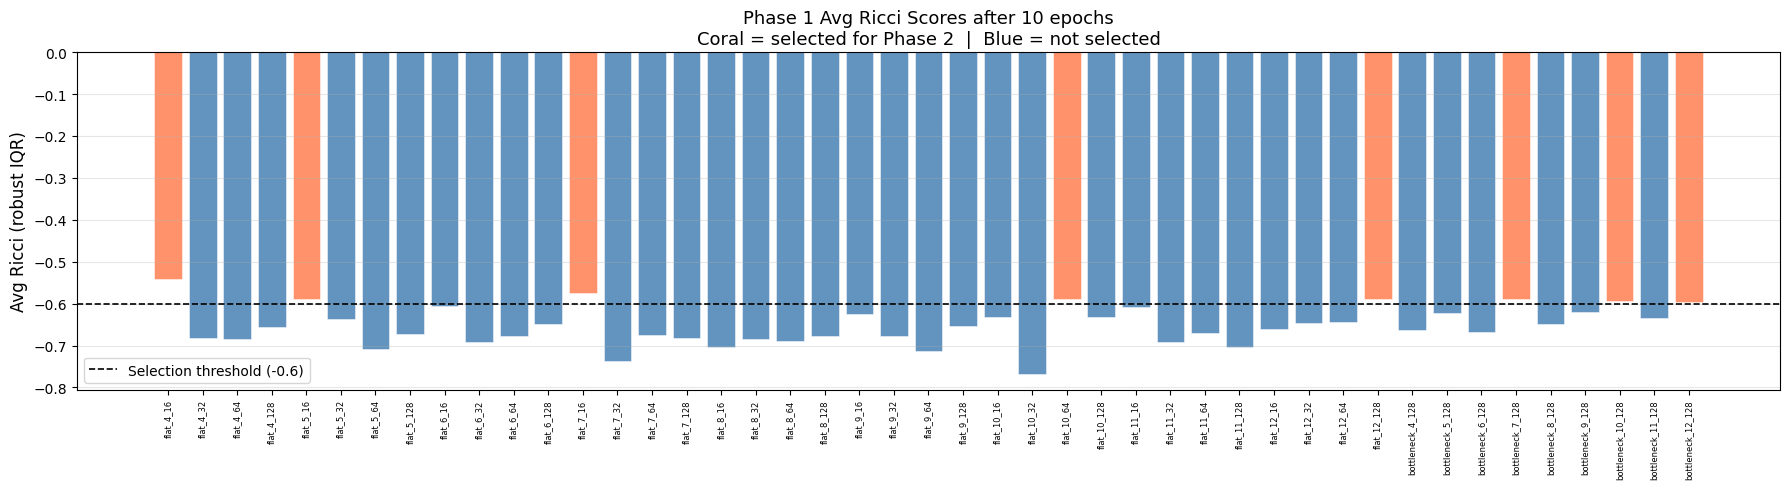

Selected: 8   Not selected: 37

Selected architectures:
  flat_4_16                       avg_ricci=-0.5419  acc_phase1=0.9730
  flat_5_16                       avg_ricci=-0.5882  acc_phase1=0.9695
  flat_7_16                       avg_ricci=-0.5750  acc_phase1=0.9535
  flat_10_64                      avg_ricci=-0.5888  acc_phase1=0.9675
  flat_12_128                     avg_ricci=-0.5881  acc_phase1=0.9690
  bottleneck_7_128                avg_ricci=-0.5882  acc_phase1=0.9710
  bottleneck_10_128               avg_ricci=-0.5930  acc_phase1=0.9610
  bottleneck_12_128               avg_ricci=-0.5963  acc_phase1=0.9560


In [ ]:
# Phase 1 results: bar chart of avg Ricci scores
p1_summary = load_json(os.path.join(OUTPUT_DIR, 'phase1_summary.json'), [])
if not p1_summary:
    print('Run Phase 1 first.')
else:
    names      = [r['name'] for r in p1_summary]
    scores     = [r['avg_ricci_phase1'] for r in p1_summary]
    selected   = [r['selected_for_phase2'] for r in p1_summary]
    colors     = ['coral' if s else 'steelblue' for s in selected]

    fig, ax = plt.subplots(figsize=(18, 5))
    x = np.arange(len(names))
    ax.bar(x, scores, color=colors, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axhline(RICCI_SELECTION_THRESHOLD, color='black', linestyle='--', linewidth=1.2,
               label=f'Selection threshold ({RICCI_SELECTION_THRESHOLD})')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=90, fontsize=6)
    ax.set_ylabel('Avg Ricci (robust IQR)', fontsize=12)
    ax.set_title(f'Phase 1 Avg Ricci Scores after {PHASE1_EPOCHS} epochs\n'
                 f'Coral = selected for Phase 2  |  Blue = not selected', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'phase1_ricci_scores.png'), dpi=300, bbox_inches='tight')
    plt.show()

    n_sel = sum(selected)
    print(f'Selected: {n_sel}   Not selected: {len(names)-n_sel}')
    print('\nSelected architectures:')
    for r in p1_summary:
        if r['selected_for_phase2']:
            print(f'  {r["name"]:30s}  avg_ricci={r["avg_ricci_phase1"]:+.4f}  '
                  f'acc_phase1={r["final_test_acc_phase1"]:.4f}')


In [ ]:
 # ═══════════════════════════════════════════════════════════════════════════════
# PHASE 2 — EXTENDED RUN  (PHASE2_EPOCHS epochs, selected architectures only)
# ═══════════════════════════════════════════════════════════════════════════════
#
# For each selected architecture we:
#   1. Re-initialise the model from scratch (fresh weights, fair comparison).
#   2. Train for PHASE2_EPOCHS epochs with NO forced stopping.
#   3. At every epoch:
#        - evaluate train/test accuracy
#        - compute layer Ricci on test-set hidden activations
#        - run StandardEarlyStopping as a PASSIVE observer (records when it
#          would have stopped, but never actually stops training)
#        - run RicciEarlyStopping as a PASSIVE observer (patience-based on
#          avg Ricci — records when it would have stopped)
#        - save activations, layer_ricci, accuracy to per-epoch subfolder
#   4. At the end, save:
#        - model weights at best standard-ES epoch  (model_weights_std_es.pth)
#        - model weights at best Ricci-ES epoch     (model_weights_ricci_es.pth)
#        - model weights at final epoch             (model_weights_final.pth)
#        - full epoch_history_phase2.json
#        - summary entry in phase2_summary.json
#
# Checkpoint: phase2_checkpoint.json — safe to re-run after disconnect.
# ───────────────────────────────────────────────────────────────────────────────

p1_summary  = load_json(os.path.join(OUTPUT_DIR, 'phase1_summary.json'), [])
selected    = [r for r in p1_summary if r['selected_for_phase2']]

if not selected:
    print('No architectures selected. Check RICCI_SELECTION_THRESHOLD or run Phase 1 first.')
else:
    p2_ckpt      = load_json(PHASE2_CKPT, {'completed': []})
    p2_completed = set(p2_ckpt['completed'])

    p2_summary_path = os.path.join(OUTPUT_DIR, 'phase2_summary.json')
    p2_summary      = load_json(p2_summary_path, [])

    t0 = time.time()

    for run_idx, p1_entry in enumerate(selected):
        name      = p1_entry['name']
        arch_type = p1_entry['type']
        depth     = p1_entry['depth']
        width     = p1_entry['width']

        if name in p2_completed:
            print(f'[{run_idx+1:2d}/{len(selected)}] {name} — skipped (checkpoint)')
            continue

        print(f'\n[{run_idx+1:2d}/{len(selected)}] {name}  '
              f'(type={arch_type}, depth={depth}, width={width})')
        print(f'  Phase 1 avg_ricci={p1_entry["avg_ricci_phase1"]:+.4f}  '
              f'Phase 1 acc={p1_entry["final_test_acc_phase1"]:.4f}')

        arch_dir = os.path.join(PHASE2_DIR, name)
        os.makedirs(arch_dir, exist_ok=True)

        # ── fresh model
        model     = build_model(arch_type, depth, width)
        loss_fn   = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)

        std_es             = StandardEarlyStopping(patience=PATIENCE)
        ricci_es           = RicciEarlyStopping(patience=PATIENCE)
        std_best_weights   = None
        ricci_best_weights = None

        epoch_history = []

        for epoch in range(PHASE2_EPOCHS):

            # 1. train
            train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)

            # 2. evaluate
            test_acc,  test_loss  = evaluate(model, X_test,  y_test)
            train_acc, train_loss2 = evaluate(model, X_train, y_train)

            # 3. Ricci on hidden activations
            model.eval()
            with torch.inference_mode():
                feats = model.features(X_test)   # [input, h1..hL], output excluded

            hidden_acts = feats[1:]
            if len(hidden_acts) < 2:
                raise ValueError(f'{name}: need >=2 hidden layers, got {len(hidden_acts)}')

            layer_ricci = compute_ricci_from_features(hidden_acts, K, curv=CURVATURE_TYPE)
            # Plain nanmean — all layers included, consistent with Phase 1 scoring.
            avg_ricci   = float(np.nanmean(layer_ricci))

            # 4A. passive standard ES observer
            std_es.step(epoch, test_acc)
            if std_es.best_epoch == epoch:
                std_best_weights = copy.deepcopy(model.state_dict())

            if std_es.stop_epoch == epoch:
                print(f'  [passive] Standard ES would stop at epoch {epoch} '
                      f'(best_epoch={std_es.best_epoch}, best_acc={std_es.best_acc:.4f})')

            # 4B. passive Ricci ES observer
            ricci_es.step(epoch, avg_ricci)
            if ricci_es.best_epoch == epoch:
                ricci_best_weights = copy.deepcopy(model.state_dict())

            if ricci_es.stop_epoch == epoch:
                print(f'  [passive] Ricci ES would stop at epoch {epoch} '
                      f'(best_epoch={ricci_es.best_epoch}, best_ricci={ricci_es.best_ricci:.4f})')

            # 5. save per-epoch data to disk
            epoch_dir = os.path.join(arch_dir, f'epoch_{epoch:04d}')
            os.makedirs(epoch_dir, exist_ok=True)

            # activations (one .npy per hidden layer)
            save_activations(epoch_dir, hidden_acts)

            # layer ricci
            np.save(os.path.join(epoch_dir, 'layer_ricci.npy'), layer_ricci)

            # scalar metrics
            np.save(os.path.join(epoch_dir, 'metrics.npy'),
                    np.array([train_acc, test_acc, train_loss, test_loss]))

            # 6. record epoch entry
            epoch_history.append({
                'epoch':        epoch,
                'train_acc':    float(train_acc),
                'test_acc':     float(test_acc),
                'train_loss':   float(train_loss),
                'test_loss':    float(test_loss),
                'avg_ricci':    float(avg_ricci),
                'layer_ricci':  layer_ricci.tolist(),
            })

            if (epoch + 1) % 20 == 0 or epoch == PHASE2_EPOCHS - 1:
                print(f'  ep {epoch:4d}: train={train_acc:.4f}  test={test_acc:.4f}  '
                      f'avg_ricci={avg_ricci:+.4f}')

        # ── end of training — save weights
        # model at standard ES best epoch
        if std_best_weights is not None:
            torch.save(std_best_weights,
                       os.path.join(arch_dir, 'model_weights_std_es.pth'))
        else:
            torch.save(model.state_dict(),
                       os.path.join(arch_dir, 'model_weights_std_es.pth'))

        # model at Ricci ES best epoch
        if ricci_best_weights is not None:
            torch.save(ricci_best_weights,
                       os.path.join(arch_dir, 'model_weights_ricci_es.pth'))
        else:
            torch.save(model.state_dict(),
                       os.path.join(arch_dir, 'model_weights_ricci_es.pth'))

        # model at final epoch
        torch.save(model.state_dict(),
                   os.path.join(arch_dir, 'model_weights_final.pth'))

        # full epoch history
        save_json(os.path.join(arch_dir, 'epoch_history_phase2.json'), epoch_history)

        # ── build summary entry
        last_ep          = len(epoch_history) - 1
        std_es_report_ep = std_es.best_epoch if std_es.best_epoch is not None else last_ep
        std_es_report_ep = max(0, min(int(std_es_report_ep), last_ep))

        ricci_es_report_ep = ricci_es.best_epoch if ricci_es.best_epoch is not None else last_ep
        ricci_es_report_ep = max(0, min(int(ricci_es_report_ep), last_ep))

        std_es_acc   = float(epoch_history[std_es_report_ep]['test_acc'])
        ricci_es_acc = float(epoch_history[ricci_es_report_ep]['test_acc'])
        final_acc    = float(epoch_history[last_ep]['test_acc'])
        final_ricci  = float(epoch_history[last_ep]['avg_ricci'])

        # find epoch where Ricci is most negative (geometric convergence point)
        ricci_values     = [e['avg_ricci'] for e in epoch_history]
        ricci_min_epoch  = int(np.nanargmin(ricci_values))
        ricci_min_acc    = float(epoch_history[ricci_min_epoch]['test_acc'])

        summary_entry = {
            'name':                   name,
            'type':                   arch_type,
            'depth':                  depth,
            'width':                  width,
            # Phase 1 reference
            'avg_ricci_phase1':       p1_entry['avg_ricci_phase1'],
            'acc_phase1':             p1_entry['final_test_acc_phase1'],
            # Phase 2 standard ES (passive)
            'std_es_epoch':           std_es_report_ep,
            'std_es_stopped':         std_es.stop_epoch is not None,
            'std_stop_epoch':         std_es.stop_epoch,
            'std_es_acc':             std_es_acc,
            # Phase 2 Ricci ES (passive — patience-based)
            'ricci_es_epoch':         ricci_es_report_ep,
            'ricci_es_stopped':       ricci_es.stop_epoch is not None,
            'ricci_stop_epoch':       ricci_es.stop_epoch,
            'ricci_es_acc':           ricci_es_acc,
            'ricci_es_best_ricci':    ricci_es.best_ricci,
            # Phase 2 Ricci minimum (post-hoc argmin)
            'ricci_min_epoch':        ricci_min_epoch,
            'ricci_min_acc':          ricci_min_acc,
            'ricci_at_ricci_min':     float(ricci_values[ricci_min_epoch]),
            # Phase 2 final
            'final_acc_phase2':       final_acc,
            'final_ricci_phase2':     final_ricci,
            'total_epochs_phase2':    len(epoch_history),
        }
        p2_summary.append(summary_entry)
        save_json(p2_summary_path, p2_summary)

        # print ES status
        std_status   = f'would stop at ep {std_es.stop_epoch}' if std_es.stop_epoch is not None else 'never triggered'
        ricci_status = f'would stop at ep {ricci_es.stop_epoch}' if ricci_es.stop_epoch is not None else 'never triggered'
        print(f'  Standard ES: best_epoch={std_es_report_ep} (acc={std_es_acc:.4f}) [{std_status}]')
        print(f'  Ricci ES:    best_epoch={ricci_es_report_ep} (acc={ricci_es_acc:.4f}) [{ricci_status}]')

        # checkpoint
        p2_completed.add(name)
        save_json(PHASE2_CKPT, {'completed': list(p2_completed)})

        del model, optimizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f'\n\u2705 Phase 2 complete in {time.time()-t0:.0f}s')
    print(f'   Results saved to {p2_summary_path}')


[ 1/8] flat_4_16 — skipped (checkpoint)
[ 2/8] flat_5_16 — skipped (checkpoint)
[ 3/8] flat_7_16 — skipped (checkpoint)
[ 4/8] flat_10_64 — skipped (checkpoint)
[ 5/8] flat_12_128 — skipped (checkpoint)
[ 6/8] bottleneck_7_128 — skipped (checkpoint)
[ 7/8] bottleneck_10_128 — skipped (checkpoint)

[ 8/8] bottleneck_12_128  (type=bottleneck, depth=12, width=128)
  Phase 1 avg_ricci=-0.5963  Phase 1 acc=0.9560
  [passive] Ricci ES would stop at epoch 7 (best_epoch=2, best_ricci=-0.6415)
  ep   19: train=0.9690  test=0.9515  avg_ricci=-0.5722
  [passive] Standard ES would stop at epoch 30 (best_epoch=25, best_acc=0.9590)
  ep   39: train=0.9863  test=0.9665  avg_ricci=-0.5839
  ep   59: train=0.9847  test=0.9575  avg_ricci=-0.5884
  ep   79: train=0.9954  test=0.9665  avg_ricci=-0.5836
  ep   99: train=0.9968  test=0.9635  avg_ricci=-0.5958
  ep  119: train=0.9960  test=0.9675  avg_ricci=-0.6011
  ep  139: train=0.9971  test=0.9630  avg_ricci=-0.5988
  ep  159: train=0.9974  test=0.9660  

In [ ]:
# Phase 2 results: summary table
p2_summary = load_json(os.path.join(OUTPUT_DIR, 'phase2_summary.json'), [])
if not p2_summary:
    print('Run Phase 2 first.')
else:
    hdr = (f'{"Architecture":<26} {"P1 Ricci":>9} {"P1 Acc":>7} '
           f'{"StdES Ep":>9} {"StdES Acc":>10} '
           f'{"RicciES Ep":>11} {"RicciES Acc":>12} '
           f'{"RicciMin Ep":>12} {"RicciMin Acc":>13} '
           f'{"Final Acc":>10}')
    print(hdr)
    print('-' * len(hdr))
    for r in p2_summary:
        print(f'{r["name"]:<26} '
              f'{r["avg_ricci_phase1"]:>+9.4f} '
              f'{r["acc_phase1"]:>7.4f} '
              f'{r["std_es_epoch"]:>9d} '
              f'{r["std_es_acc"]:>10.4f} '
              f'{r["ricci_es_epoch"]:>11d} '
              f'{r["ricci_es_acc"]:>12.4f} '
              f'{r["ricci_min_epoch"]:>12d} '
              f'{r["ricci_min_acc"]:>13.4f} '
              f'{r["final_acc_phase2"]:>10.4f}')

    print(f'\nMean final acc (Phase 2, 200 ep): {np.mean([r["final_acc_phase2"] for r in p2_summary]):.4f}')
    print(f'Mean std ES acc (Phase 2):         {np.mean([r["std_es_acc"]       for r in p2_summary]):.4f}')
    print(f'Mean Ricci ES acc (Phase 2):       {np.mean([r["ricci_es_acc"]     for r in p2_summary]):.4f}')
    print(f'Mean Phase 1 acc:                  {np.mean([r["acc_phase1"]        for r in p2_summary]):.4f}')


Architecture                P1 Ricci  P1 Acc  StdES Ep  StdES Acc  RicciES Ep  RicciES Acc  RicciMin Ep  RicciMin Acc  Final Acc
--------------------------------------------------------------------------------------------------------------------------------
flat_4_16                    -0.5419  0.9730        19     0.9765           1       0.9130            1        0.9130     0.9775
flat_5_16                    -0.5882  0.9695        18     0.9750           4       0.9600            4        0.9600     0.9780
flat_7_16                    -0.5750  0.9535         8     0.9615           1       0.8660           44        0.9645     0.9685
flat_10_64                   -0.5888  0.9675        25     0.9750           4       0.9630           97        0.9790     0.9765
flat_12_128                  -0.5881  0.9690         6     0.9690          15       0.9735          164        0.9795     0.9830
bottleneck_7_128             -0.5882  0.9710        11     0.9690           1       0.9425       

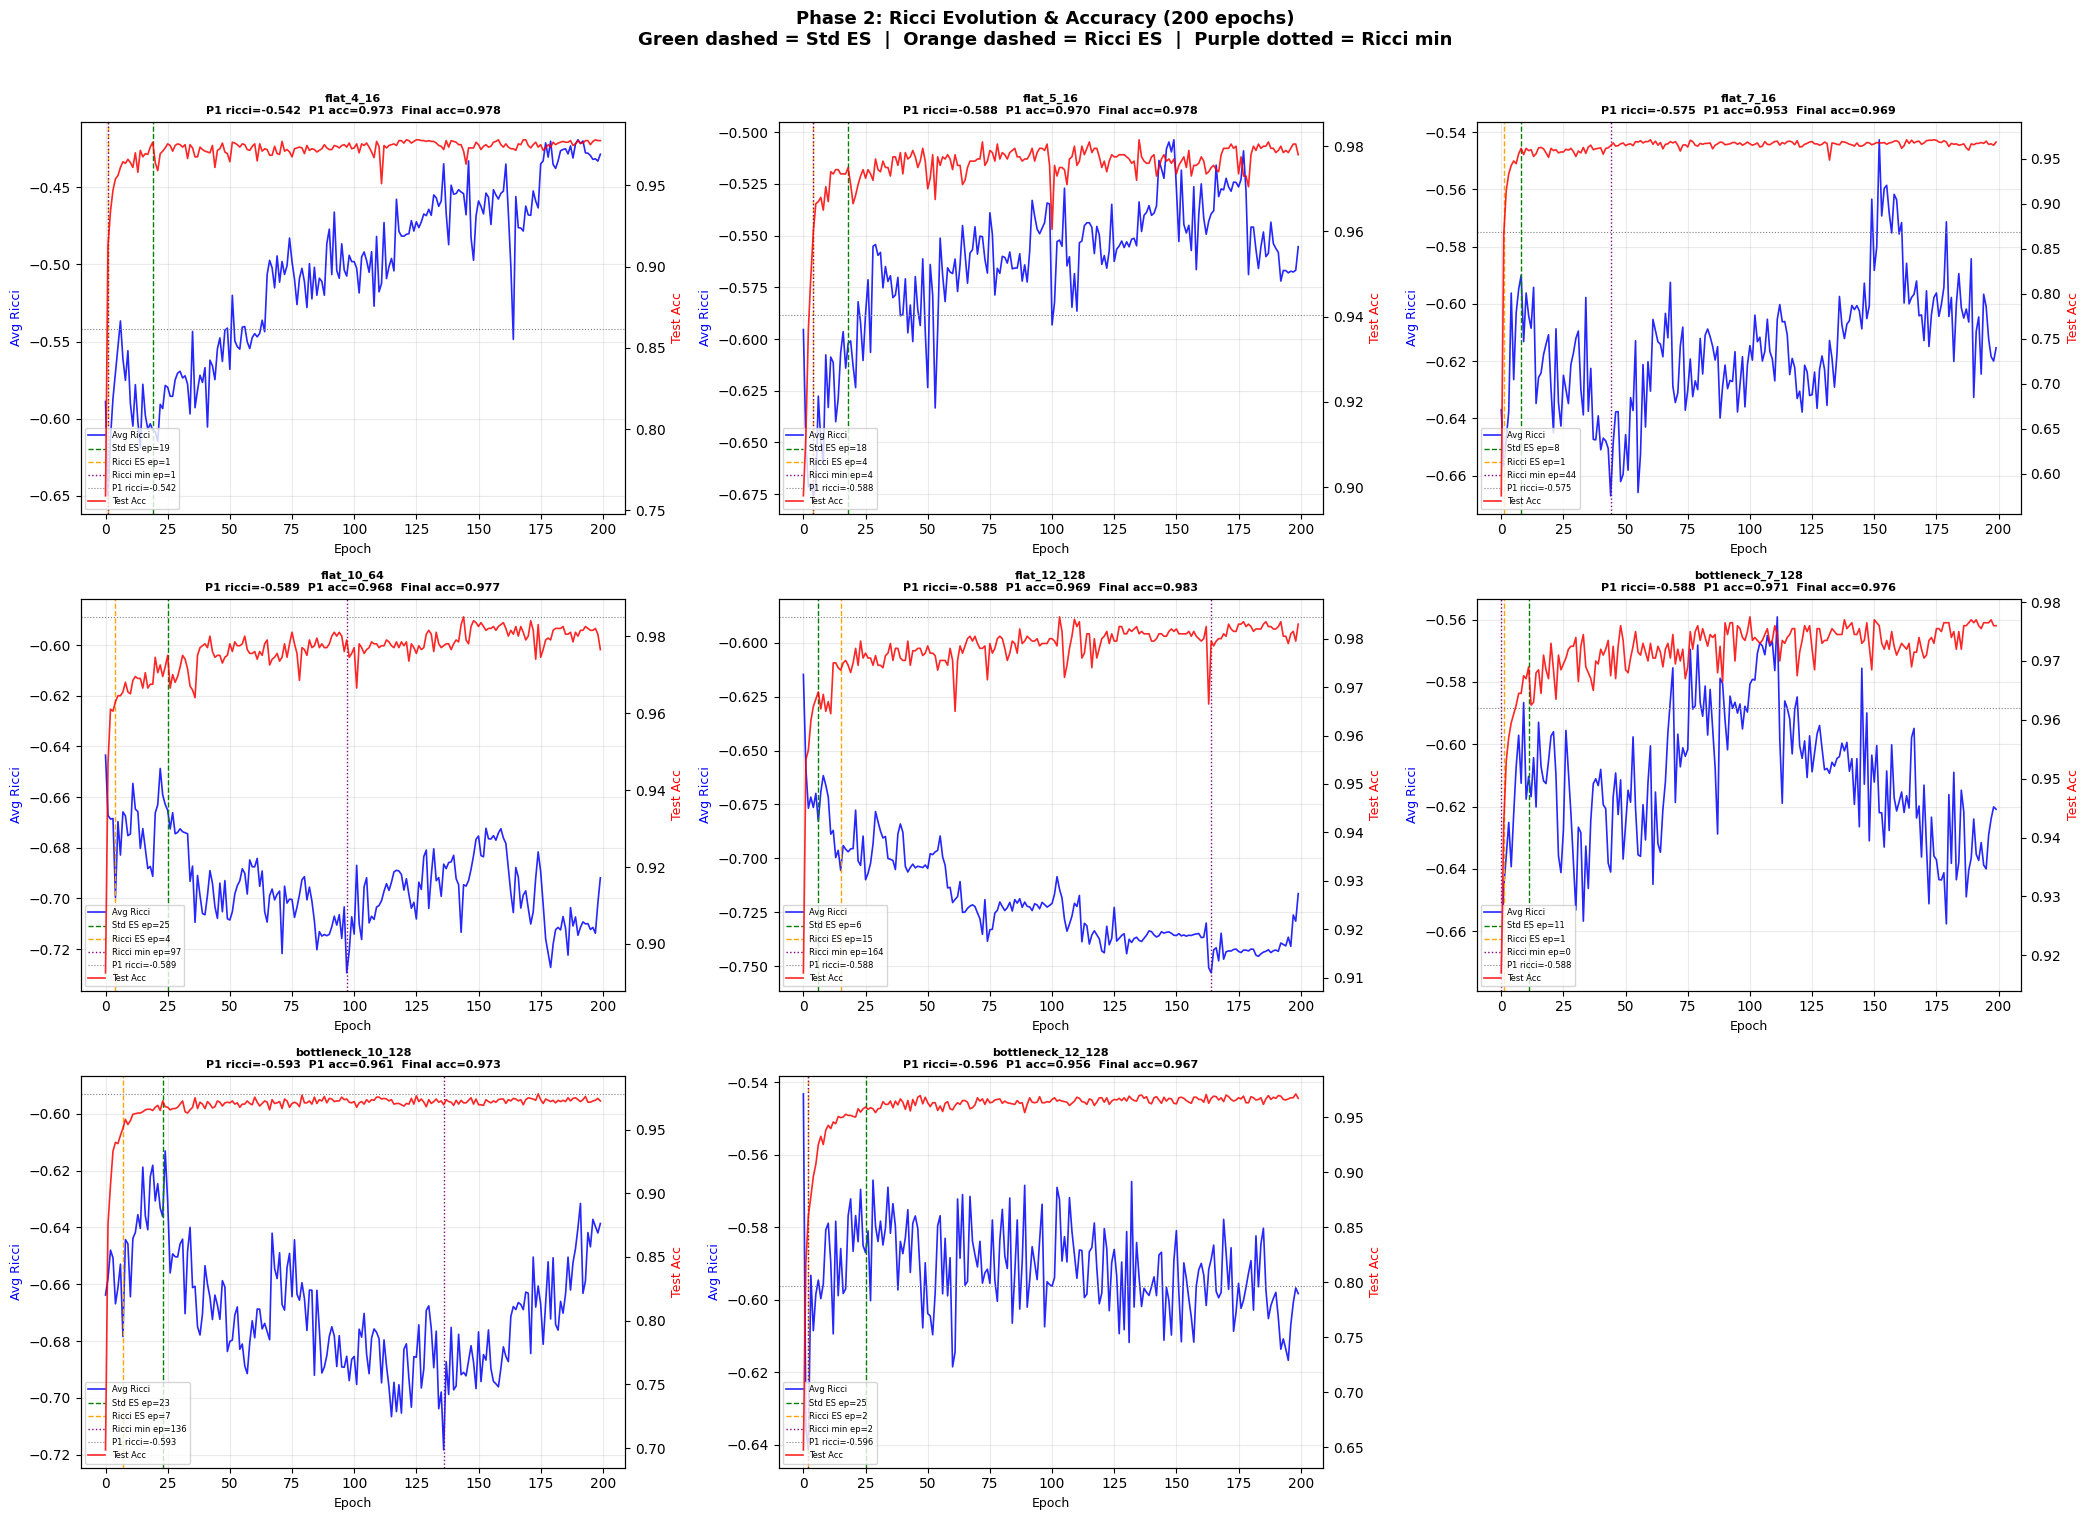

✅ Saved → /content/drive/MyDrive/Ricci_Flow_Experiment/two_phase_experiment/phase2_ricci_evolution.png


In [ ]:
# Phase 2: twin-axis plots (avg Ricci + test accuracy over 200 epochs)
p2_summary = load_json(os.path.join(OUTPUT_DIR, 'phase2_summary.json'), [])
if not p2_summary:
    print('Run Phase 2 first.')
else:
    n   = len(p2_summary)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axes = axes.flatten()

    for idx, r in enumerate(p2_summary):
        ax   = axes[idx]
        name = r['name']
        hist_path = os.path.join(PHASE2_DIR, name, 'epoch_history_phase2.json')
        if not os.path.exists(hist_path):
            ax.set_visible(False); continue

        history  = load_json(hist_path, [])
        epochs   = [h['epoch']    for h in history]
        ricci    = [h['avg_ricci'] for h in history]
        test_acc = [h['test_acc']  for h in history]

        ax2 = ax.twinx()
        ax.plot(epochs, ricci,    'b-', lw=1.2, alpha=0.85, label='Avg Ricci')
        ax2.plot(epochs, test_acc, 'r-', lw=1.2, alpha=0.85, label='Test Acc')

        # standard ES passive marker
        std_ep = r['std_es_epoch']
        ax.axvline(std_ep, color='green',  ls='--', lw=1.0,
                   label=f'Std ES ep={std_ep}')

        # Ricci ES passive marker (patience-based)
        ricci_es_ep = r['ricci_es_epoch']
        ax.axvline(ricci_es_ep, color='orange', ls='--', lw=1.0,
                   label=f'Ricci ES ep={ricci_es_ep}')

        # Ricci minimum marker (post-hoc argmin)
        ri_ep  = r['ricci_min_epoch']
        ax.axvline(ri_ep,  color='purple', ls=':',  lw=1.0,
                   label=f'Ricci min ep={ri_ep}')

        # phase 1 reference line
        ax.axhline(r['avg_ricci_phase1'], color='gray', ls=':', lw=0.8,
                   label=f'P1 ricci={r["avg_ricci_phase1"]:+.3f}')

        ax.set_xlabel('Epoch', fontsize=9)
        ax.set_ylabel('Avg Ricci',  color='blue',  fontsize=9)
        ax2.set_ylabel('Test Acc',  color='red',   fontsize=9)
        ax.set_title(f'{name}\n'
                     f'P1 ricci={r["avg_ricci_phase1"]:+.3f}  '
                     f'P1 acc={r["acc_phase1"]:.3f}  '
                     f'Final acc={r["final_acc_phase2"]:.3f}',
                     fontsize=8, fontweight='bold')

        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=6, loc='lower left')
        ax.grid(True, alpha=0.25)

    for i in range(len(p2_summary), len(axes)):
        axes[i].set_visible(False)

    plt.suptitle('Phase 2: Ricci Evolution & Accuracy (200 epochs)\n'
                 'Green dashed = Std ES  |  Orange dashed = Ricci ES  |  Purple dotted = Ricci min',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'phase2_ricci_evolution.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'\u2705 Saved \u2192 {save_path}')


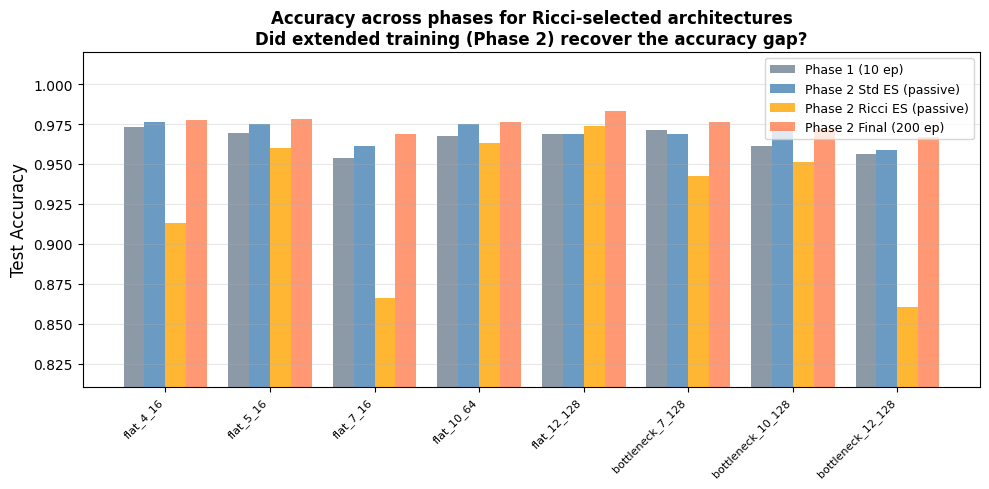

✅ Saved → /content/drive/MyDrive/Ricci_Flow_Experiment/two_phase_experiment/phase_accuracy_comparison.png

Architecture                  P1 acc   StdES acc   RicciES acc   Final acc   Gain vs P1
--------------------------------------------------------------------------------------
flat_4_16                     0.9730      0.9765        0.9130      0.9775      +0.0045
flat_5_16                     0.9695      0.9750        0.9600      0.9780      +0.0085
flat_7_16                     0.9535      0.9615        0.8660      0.9685      +0.0150
flat_10_64                    0.9675      0.9750        0.9630      0.9765      +0.0090
flat_12_128                   0.9690      0.9690        0.9735      0.9830      +0.0140
bottleneck_7_128              0.9710      0.9690        0.9425      0.9760      +0.0050
bottleneck_10_128             0.9610      0.9725        0.9510      0.9725      +0.0115
bottleneck_12_128             0.9560      0.9590        0.8605      0.9670      +0.0110


In [ ]:
# ── Cross-phase comparison: did extended training help?
p2_summary = load_json(os.path.join(OUTPUT_DIR, 'phase2_summary.json'), [])
p1_summary  = load_json(os.path.join(OUTPUT_DIR, 'phase1_summary.json'), [])

if not p2_summary:
    print('Run Phase 2 first.')
else:
    names      = [r['name']              for r in p2_summary]
    acc_p1     = [r['acc_phase1']        for r in p2_summary]
    acc_std    = [r['std_es_acc']        for r in p2_summary]
    acc_ricci  = [r['ricci_es_acc']      for r in p2_summary]
    acc_final  = [r['final_acc_phase2']  for r in p2_summary]

    x  = np.arange(len(names))
    w  = 0.20

    fig, ax = plt.subplots(figsize=(max(10, len(names) * 1.0), 5))
    ax.bar(x - 1.5*w, acc_p1,    w, label=f'Phase 1 ({PHASE1_EPOCHS} ep)',  color='slategray', alpha=0.8)
    ax.bar(x - 0.5*w, acc_std,   w, label='Phase 2 Std ES (passive)',        color='steelblue', alpha=0.8)
    ax.bar(x + 0.5*w, acc_ricci, w, label='Phase 2 Ricci ES (passive)',      color='orange',    alpha=0.8)
    ax.bar(x + 1.5*w, acc_final, w, label=f'Phase 2 Final ({PHASE2_EPOCHS} ep)', color='coral', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Test Accuracy', fontsize=12)
    ax.set_title('Accuracy across phases for Ricci-selected architectures\n'
                 'Did extended training (Phase 2) recover the accuracy gap?',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(max(0, min(acc_p1 + acc_std + acc_ricci + acc_final) - 0.05), 1.02)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'phase_accuracy_comparison.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'\u2705 Saved \u2192 {save_path}')

    # ── print gain
    print(f'\n{"Architecture":<26}  {"P1 acc":>8}  {"StdES acc":>10}  {"RicciES acc":>12}  {"Final acc":>10}  {"Gain vs P1":>11}')
    print('-' * 86)
    for r in p2_summary:
        gain = r['final_acc_phase2'] - r['acc_phase1']
        print(f'{r["name"]:<26}  {r["acc_phase1"]:>8.4f}  '
              f'{r["std_es_acc"]:>10.4f}  {r["ricci_es_acc"]:>12.4f}  '
              f'{r["final_acc_phase2"]:>10.4f}  {gain:>+11.4f}')


In [ ]:
# ── Export full comparison CSV
import csv

p1_summary = load_json(os.path.join(OUTPUT_DIR, 'phase1_summary.json'), [])
p2_summary = load_json(os.path.join(OUTPUT_DIR, 'phase2_summary.json'), [])
p2_by_name = {r['name']: r for r in p2_summary}

rows = []
for r1 in p1_summary:
    name = r1['name']
    r2   = p2_by_name.get(name)
    row  = {
        'name':                   name,
        'type':                   r1['type'],
        'depth':                  r1['depth'],
        'width':                  r1['width'],
        'selected_for_phase2':    r1['selected_for_phase2'],
        'avg_ricci_phase1':       r1['avg_ricci_phase1'],
        'acc_phase1':             r1['final_test_acc_phase1'],
        # phase 2 columns — NaN for non-selected
        'std_es_epoch_phase2':    r2['std_es_epoch']         if r2 else float('nan'),
        'std_es_acc_phase2':      r2['std_es_acc']           if r2 else float('nan'),
        'ricci_es_epoch_phase2':  r2['ricci_es_epoch']       if r2 else float('nan'),
        'ricci_es_acc_phase2':    r2['ricci_es_acc']         if r2 else float('nan'),
        'ricci_min_epoch_phase2': r2['ricci_min_epoch']      if r2 else float('nan'),
        'ricci_min_acc_phase2':   r2['ricci_min_acc']        if r2 else float('nan'),
        'final_acc_phase2':       r2['final_acc_phase2']     if r2 else float('nan'),
        'final_ricci_phase2':     r2['final_ricci_phase2']   if r2 else float('nan'),
    }
    rows.append(row)

csv_path = os.path.join(OUTPUT_DIR, 'two_phase_results.csv')
with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    w.writeheader()
    w.writerows(rows)

print(f'\u2705 Saved {len(rows)} rows \u2192 {csv_path}')


✅ Saved 45 rows → /content/drive/MyDrive/Ricci_Flow_Experiment/two_phase_experiment/two_phase_results.csv
